In [1]:
# This cell installs the RDKit library, which is used for cheminformatics tasks.
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 48.2 MB/s eta 0:00:00


1. Import Liabraries

In [2]:
import warnings
warnings.filterwarnings('ignore')

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import AllChem

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report
from sklearn.linear_model import LinearRegression

Read CSV

In [4]:
data = pd.read_csv('drugs_dataset.csv')

### 2. Data Cleaning
This section focuses on preparing the dataset by removing unnecessary columns and handling missing values.

In [5]:
# This cell defines a list of columns to be dropped from the DataFrame.
# These columns are either identifiers or will be recreated/are not needed for modeling.
drop_cols = [
    'Name', 'Synonyms', 'InChI', 'InChIKey',
    'IUPAC_Name', 'Create_Date', 'fingerprint'
]

# It then drops these columns, ignoring any that might not exist.
data = data.drop(columns=drop_cols, errors='ignore')

# Missing numerical values are filled with the mean of their respective columns.
data = data.fillna(data.mean(numeric_only=True))

In [6]:
# -------------------------------
# STEP 1: Convert SMILES to Fingerprints
# -------------------------------

# Defines a function to convert a SMILES string into a Morgan fingerprint.
# If the SMILES is valid, it generates a 128-bit fingerprint; otherwise, it returns None.
def smiles_to_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        # Using MorganGenerator as recommended by the deprecation warning
        fp_gen = AllChem.GetMorganGenerator(radius=2, fpSize=128)
        fp = fp_gen.GetFingerprint(mol)
        return list(fp)
    return None

# Applies the conversion function to the 'SMILES' column, creating a new 'fingerprint' column.
data['fingerprint'] = data['SMILES'].apply(smiles_to_fp)

# Removes rows where the fingerprint conversion failed (i.e., SMILES were invalid).
data = data[data['fingerprint'].notnull()]


# Converts the list of fingerprint bits into separate columns in a new DataFrame.
fp_df = pd.DataFrame(data['fingerprint'].tolist())

# Merges the new fingerprint columns back into the main 'data' DataFrame.
data = pd.concat([data, fp_df], axis=1)

### 3. Feature Selection
This section defines and selects the features (molecular descriptors and fingerprints) that will be used as input for the machine learning models.

In [7]:
# This cell defines a list of molecular descriptor features to be used in the models.
descriptor_features = [
    'Molecular_Weight', 'Polar_Area', 'Complexity',
    'Heavy_Atom_Count', 'H-Bond_Donor_Count',
    'H-Bond_Acceptor_Count', 'Rotatable_Bond_Count',
    'Exact_Mass'
]

# Filters the list to ensure only existing columns are selected.
descriptor_features = [col for col in descriptor_features if col in data.columns]

# Combines the selected molecular descriptor features and the generated fingerprint features
# into a single DataFrame 'X', which will serve as the input for machine learning models.
# Note: fp_df needs to be created first, which happens in Ds42L2p1Ec83.
X = pd.concat([data[descriptor_features], fp_df], axis=1)

# Explicitly drop any remaining NaN values from the feature matrix X before using it in models.
X.dropna(inplace=True)

### Coefficient Matrix
This section calculates and visualizes the coefficients from a Linear Regression model, showing the importance of each feature.

                Feature  Coefficient
0      Molecular_Weight     1.372853
1            Polar_Area    -0.354492
2            Complexity    -0.772394
3      Heavy_Atom_Count     1.111136
4    H-Bond_Donor_Count    -0.577181
..                  ...          ...
131                 123    -0.064256
132                 124     0.028515
133                 125     0.080483
134                 126    -0.008188
135                 127    -0.077343

[136 rows x 2 columns]


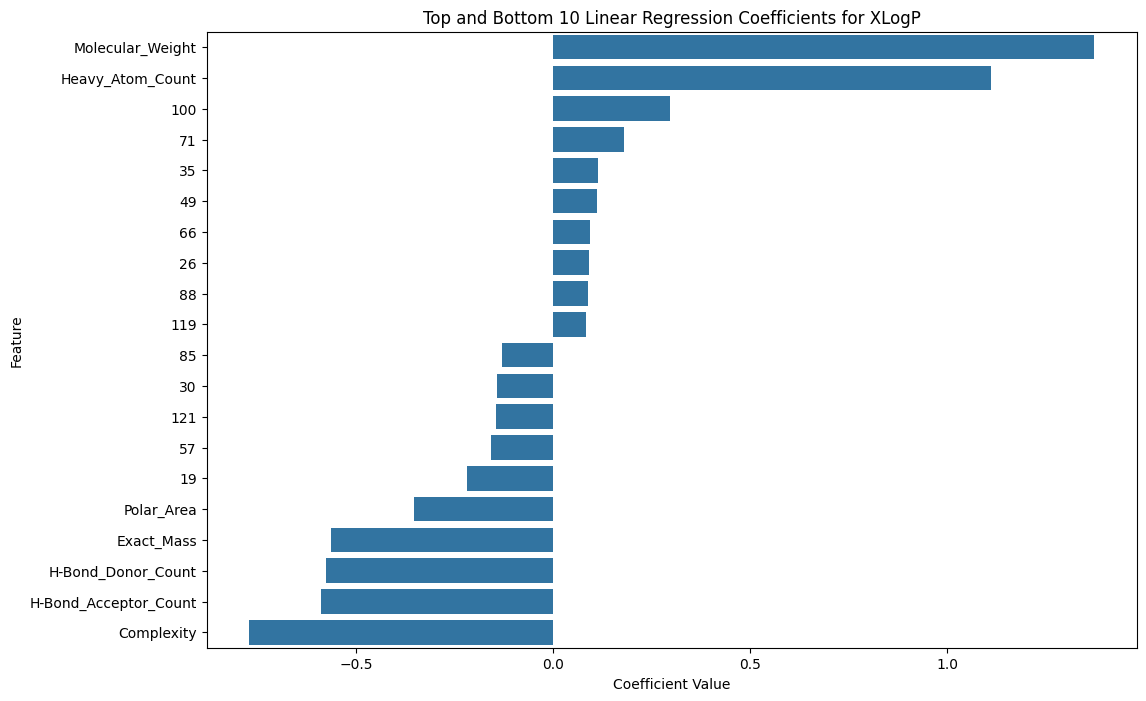

In [8]:
# Prepare regression data: selects 'XLogP' as the target variable and removes any missing values.
# Ensure X and y_reg are aligned and free of NaNs together.
# Temporarily combine X and 'XLogP' to drop rows with NaNs in either.
temp_df = pd.concat([X, data['XLogP']], axis=1, join='inner')
temp_df.dropna(inplace=True)

X_reg = temp_df.drop(columns=['XLogP'])
y_reg = temp_df['XLogP']

# Converts column names in X_reg to string type for compatibility with scikit-learn.
X_reg.columns = X_reg.columns.astype(str);
# Stores the list of feature names used for regression.
features_reg = X_reg.columns.tolist()

# Splits the data into training and testing sets for both features (X_reg) and target (y_reg).
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
# Initializes and fits a StandardScaler to the training features to normalize them.
scaler_reg = StandardScaler()
X_train_scaled_reg = scaler_reg.fit_transform(X_train_reg)

# Initializes and trains a Linear Regression model using the scaled training data.
lr_model = LinearRegression()
lr_model.fit(X_train_scaled_reg, y_train_reg)

# Creates a DataFrame to display the feature names and their corresponding coefficients from the trained model.
coef_df = pd.DataFrame({
    'Feature': features_reg,
    'Coefficient': lr_model.coef_
})
print(coef_df)

# Visualizes the top 10 and bottom 10 coefficients to highlight the most influential features.
# Sorts the coefficients from largest to smallest.
coef_df_sorted = coef_df.sort_values(by='Coefficient', ascending=False)
# Concatenates the top 10 and bottom 10 coefficients for plotting.
combined_coefs = pd.concat([coef_df_sorted.head(10), coef_df_sorted.tail(10)])

# Creates a bar plot to visualize the combined coefficients.
plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', data=combined_coefs)
plt.title('Top and Bottom 10 Linear Regression Coefficients for XLogP')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()

### 1. Regression
This section builds and evaluates a regression model to predict a continuous target variable (`XLogP`).

In [9]:
# This cell prepares data and trains a RandomForestRegressor model.

# Selects 'XLogP' as the target variable for regression.
y_reg = data['XLogP']

# Filters the input features (X) to align with non-null 'XLogP' values.
X_reg = X[~y_reg.isnull()]
# Removes null values from the target variable.
y_reg = y_reg.dropna()

# Converts column names of X_reg to string type for scikit-learn compatibility.
X_reg.columns = X_reg.columns.astype(str)

# Splits the data into training and testing sets (80% train, 20% test).
X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Initializes and fits a StandardScaler to the training features, then transforms both training and testing features.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initializes and trains a RandomForestRegressor model with 100 estimators.
model_reg = RandomForestRegressor(n_estimators=100, random_state=42)
model_reg.fit(X_train, y_train)

# Makes predictions on the scaled test set.
y_pred = model_reg.predict(X_test)

# Prints the Mean Squared Error (MSE) and R2 Score to evaluate the model's performance.
print("\nRegression Results:")
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


Regression Results:
MSE: 0.8539239637755042
R2 Score: 0.8094677363532687


### 2. Classification
This section demonstrates how to perform a classification task, categorizing drugs based on molecular weight.

In [10]:
# This cell performs a classification task based on molecular weight.

# Defines a function to classify drugs into 'Light', 'Medium', or 'Heavy' based on their molecular weight.
def classify_weight(weight):
    if weight < 300:
        return "Light"
    elif weight <= 500:
        return "Medium"
    else:
        return "Heavy"

# Applies the classification function to the 'Molecular_Weight' column, creating a new 'Drug_Class' column.
data['Drug_Class'] = data['Molecular_Weight'].apply(classify_weight)

# Selects 'Drug_Class' as the target variable for classification.
y_cls = data['Drug_Class']

# Converts column names of X to string type for scikit-learn compatibility.
X.columns = X.columns.astype(str)

# Splits the data into training and testing sets for both features (X) and target (y_cls).
X_train, X_test, y_train, y_test = train_test_split(X, y_cls, test_size=0.2, random_state=42)

# Scales the training and testing features using StandardScaler.
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initializes and trains a RandomForestClassifier model with 100 estimators.
model_cls = RandomForestClassifier(n_estimators=100, random_state=42)
model_cls.fit(X_train, y_train)

# Makes predictions on the scaled test set.
y_pred = model_cls.predict(X_test)

# Prints classification results: Accuracy Score and a detailed Classification Report.
print("\nClassification Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Classification Results:
Accuracy: 0.9968847352024922
              precision    recall  f1-score   support

       Heavy       1.00      1.00      1.00         1
       Light       1.00      1.00      1.00       292
      Medium       0.97      1.00      0.98        28

    accuracy                           1.00       321
   macro avg       0.99      1.00      0.99       321
weighted avg       1.00      1.00      1.00       321



### Visualize XLogP
This section visualizes the distribution of the `XLogP` values in the dataset.

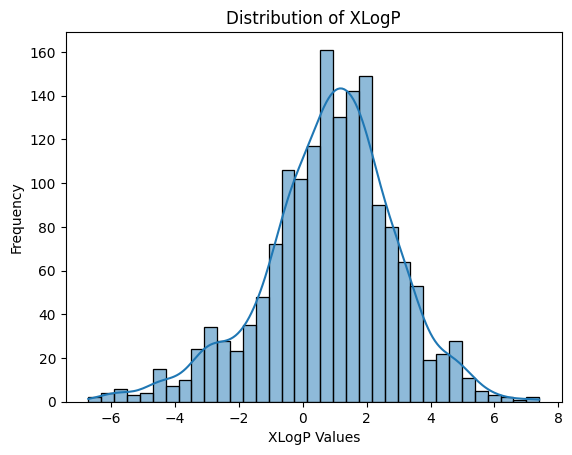

In [11]:
# This cell generates a histogram to visualize the distribution of 'XLogP' values.
# A KDE (Kernel Density Estimate) curve is overlaid to show the probability density.
plt.figure()
sns.histplot(data['XLogP'], kde=True)

# Sets the title and labels for the plot axes.
plt.title("Distribution of XLogP")
plt.xlabel("XLogP Values")
plt.ylabel("Frequency")

# Displays the generated plot.
plt.show()

### Visualise Drug Classes
This section visualizes the distribution of drug classes based on molecular weight.

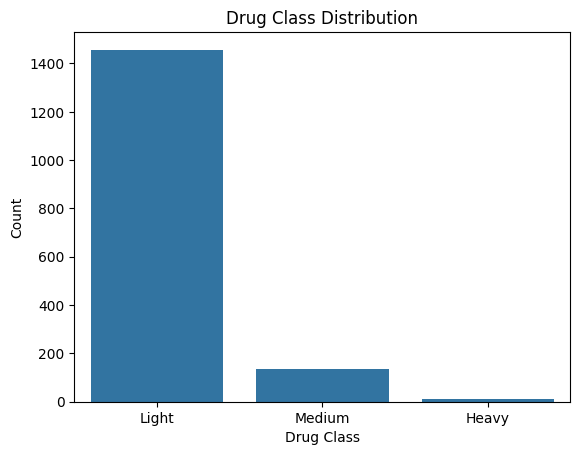

In [12]:
# This cell generates a count plot to visualize the distribution of 'Drug_Class' categories.
plt.figure()
sns.countplot(x=data['Drug_Class'])

# Sets the title and labels for the plot axes.
plt.title("Drug Class Distribution")
plt.xlabel("Drug Class")
plt.ylabel("Count")

# Displays the generated plot.
plt.show()

### Comparing Regression Algorithms: RandomForestRegressor vs. LinearRegression
This section compares the performance of two different regression algorithms.

In [13]:
# This cell compares the performance of RandomForestRegressor and LinearRegression models.

# Ensure X_reg and y_reg are defined (they should be from previous cells)
# The X DataFrame should already be clean of NaNs from pHmAibaZ3lC_, so X_reg derived from it will also be clean.

# Ensure X and y_reg are aligned and free of NaNs together.
# Temporarily combine X and 'XLogP' to drop rows with NaNs in either.
temp_df = pd.concat([X, data['XLogP']], axis=1, join='inner')
temp_df.dropna(inplace=True)

X_reg = temp_df.drop(columns=['XLogP'])
y_reg = temp_df['XLogP']

# Ensure column names are strings for scikit-learn compatibility
X_reg.columns = X_reg.columns.astype(str)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Scale features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 1. RandomForestRegressor Evaluation
print("\n--- RandomForestRegressor ---")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))

# 2. LinearRegression Evaluation
print("\n--- LinearRegression ---")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))


--- RandomForestRegressor ---
MSE: 0.8539239637755042
R2 Score: 0.8094677363532687

--- LinearRegression ---
MSE: 1.0716684874731732
R2 Score: 0.7608833673031653
